# Trion in a bimodal cavity

This notebook introduces the exact trion-in-a-cavity source model added to the catalogue. The model keeps the full tensor-product structure of a four-level trion coupled to two cavity modes, so it can be used as a faithful reference before any reduced single-excitation approximation is considered.

## Imports

We use the top-level ZPGenerator interface together with NumPy and Matplotlib for a small parameter sweep.

In [1]:
from zpgenerator import *
import numpy as np
import matplotlib.pyplot as plt

## Build the source

`Source.trion_cavity(...)` constructs an exact 16-dimensional model with two cavity outputs. Internally, the source keeps the direct trion emission channels in the physics model but closes and masks them by default, so the visible outputs correspond to the two cavity ports.

In [2]:
pulse = Pulse.gaussian(parameters={'area': np.pi, 'width': 1})
source = Source.trion_cavity(pulse=pulse)

source.times(), source.output.open_modes

([-6, 6, 30.0], 2)

## Relevant parameters

The cavity parameters are fully explicit. In particular, the two couplings and the two cavity resonances can be tuned independently.

In [3]:
[p for p in source.parameters if 'coupling' in p or 'resonance' in p]

['cavity_h/resonance',
 'cavity_v/resonance',
 'coupling_h',
 'coupling_v',
 'trion/resonance']

## Symmetric cavity outputs

With the default symmetric parameters, the two cavity ports behave identically.

In [4]:
source.beta(0), source.beta(1), source.g2(0), source.g2(1)

(0.1083336427201742,
 0.1083336427201742,
 0.6083527958388343,
 0.6083527802910147)

## Breaking the cavity symmetry

We can split the cavity resonances explicitly and compare the brightness of the two output ports. This is a simple way to explore how the model responds to a polarisation-dependent cavity environment.

In [5]:
def split_cavity_parameters(detuning, base=None):
    base = {} if base is None else dict(base)
    return base | {
        'cavity_h/resonance': detuning,
        'cavity_v/resonance': -detuning,
    }

detunings = np.linspace(-2, 2, 9)
beta_h = [source.beta(0, parameters=split_cavity_parameters(d)) for d in detunings]
beta_v = [source.beta(1, parameters=split_cavity_parameters(d)) for d in detunings]

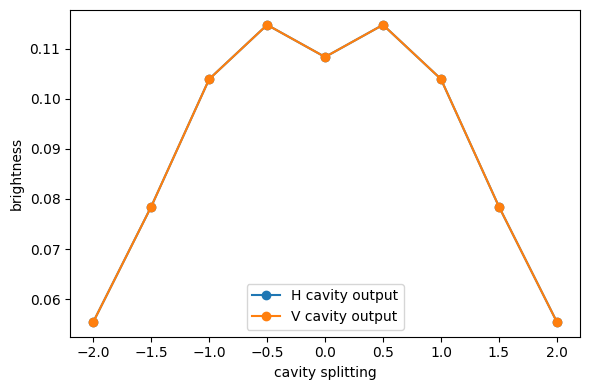

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(detunings, beta_h, 'o-', label='H cavity output')
plt.plot(detunings, beta_v, 'o-', label='V cavity output')
plt.xlabel('cavity splitting')
plt.ylabel('brightness')
plt.legend()
plt.tight_layout()
plt.show()

## Notes

This exact model is a good reference point for future approximation work. If we later introduce a reduced single-excitation description, we can validate it against the behaviour shown here rather than guessing where the approximation is reliable.